# Inference with Segment Anything Model2 (SAM2)


<img src="https://www.dropbox.com/scl/fi/1toj2z4v46z2kdd0ymada/sam2-architecture.png?rlkey=edyxytfmlq07set95ist0l1zp&st=8w0bl888&dl=1" width="100%">

---

In this notebook, we learn how to use the Segment Anything models (SAM2) to generate segmentation masks on random images.

We'll do the following:

1. Automatically generate masks for the entire image.
2. Generate masks using bounding box prompts.
3. A demo pipeline on using SAM to automatically create a semantic segmentation dataset.

## Table of Contents

* [1 Initialize SAM Checkpoint](#1-Initialize-a-SAM-Checkpoint)
* [2 Full Image Segmentation - Automatic Mask Generation](#2-Full-image-segmentation---Automatic-mask-generation)
* [3 With Bounding Box as Prompts](#3-With-Bounding-Box-as-Prompts)
* [4 Generate Semantic Segmentation Dataset with SAM](#4-Generate-Semantic-Segmentation-Dataset-Using-SAM)

Install and import the necessary libraries.

In [1]:
#!pip install transformers
#!pip install jupyter_bbox_widget requests

# Install SAM2

In [3]:
import os

os.makedirs('build_sam2', exist_ok=True)
%cd build_sam2
!git clone https://github.com/facebookresearch/sam2.git
%cd sam2
#!pip install -e .

/home/ubuntu/opencv-dl-application-m4/build_sam2/sam2/build_sam2
Cloning into 'sam2'...
remote: Enumerating objects: 1107, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 1107 (delta 5), reused 2 (delta 2), pack-reused 1098 (from 3)
Receiving objects: 100% (1107/1107), 134.92 MiB | 47.82 MiB/s, done.
Resolving deltas: 100% (381/381), done.
/home/ubuntu/opencv-dl-application-m4/build_sam2/sam2/build_sam2/sam2


In [ ]:
%cd ..

/content/build_sam2


In [ ]:
import os
import json
import base64
import requests
from copy import deepcopy
import ipywidgets as widgets

import cv2
import torch
import matplotlib
import numpy as np
from functools import partial
from typing import List, Tuple
import matplotlib.pyplot as plt

from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator, SAM2ImagePredictor
from jupyter_bbox_widget import BBoxWidget

%matplotlib inline

/content/build_sam2/sam2/sam2/modeling/sam/transformer.py:23: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


We define a function `resizeWithAspectRatio(...)` to help resize the image while maintaining the aspect ratio. Even though SAM can handle varied image sizes, too large an image can cause memory issues.

In [ ]:
def resizeWithAspectRatio(image, resize_to=1024):
    h, w, _ = image.shape

    if h > w:
        r = resize_to / float(h)
        size = (resize_to, int(w * r))
    else:
        r = resize_to / float(w)
        size = (int(h * r), resize_to)

    image = cv2.resize(image, size[::-1], interpolation=cv2.INTER_CUBIC)
    return image

Download some test images for inference demo.

In [ ]:
from zipfile import ZipFile

URL = r"https://www.dropbox.com/s/numzcrfe4fesac1/c2_m4_SAM_images_annotations.zip?dl=1"
NAME = "c2_m4_SAM_images_annotations.zip"

if not os.path.exists(NAME):
    file = requests.get(URL); open(NAME, "wb").write(file.content)
    with ZipFile(NAME) as z: z.extractall(os.getcwd())

## 1 Initialize a SAM2 Checkpoint

Loading a Segment Anything model is extremely easy. We just need to specify the model type and provide a checkpoint.

In [ ]:
mask_generator_1 = SAM2AutomaticMaskGenerator.from_pretrained("facebook/sam2.1-hiera-large")

sam2.1_hiera_large.pt:   0%|          | 0.00/898M [00:00<?, ?B/s]

## 2 Full image segmentation - Automatic mask generation

Load and resize a test image.

Original shape: (3024, 4032, 3)
Resized shape:  (768, 1024, 3)


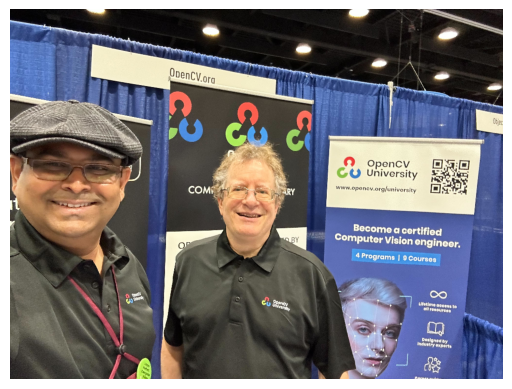

In [ ]:
DEMO_IMAGE_PATH = os.path.join(os.getcwd(), "images", "image_3.jpg")

image = cv2.imread(DEMO_IMAGE_PATH, cv2.IMREAD_COLOR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(f"Original shape: {image.shape}")

image = resizeWithAspectRatio(image)
plt.imshow(image)
plt.axis("off")

print(f"Resized shape:  {image.shape}")

Next to **generate masks** we can use the `.generate(...)` method of the `SamAutomaticMaskGenerator` class.

In [ ]:
with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    masks_1 = mask_generator_1.generate(image)

In [ ]:
print("Number of masks:", len(masks_1))

Number of masks: 72


In [ ]:
masks_1[0].keys()

dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])

In [ ]:
masks_1[0]["bbox"], masks_1[0]["predicted_iou"], masks_1[0]["point_coords"], masks_1[0]["crop_box"], masks_1[0]["stability_score"]

([0.0, 0.0, 1023.0, 200.0],
 0.98828125,
 [[1008.0, 60.0]],
 [0.0, 0.0, 1024.0, 768.0],
 0.9585620164871216)

In descending order, the `show_anns` function overlays each predicted mask on the original image. This ensures that the smaller masks aren't overlapped with bigger ones.

In [ ]:
def show_anns(anns, mask_strength=0.35):
    np.random.seed(42)

    if len(anns) == 0:
        return

    anns = sorted(anns, key=(lambda x: x["area"]), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((anns[0]["segmentation"].shape[0], anns[0]["segmentation"].shape[1], 4))
    img[:, :, 3] = 0

    for ann in anns:
        m = ann["segmentation"]
        color_mask = np.concatenate([np.random.random(3), [mask_strength]])
        img[m] = color_mask

    ax.imshow(img)

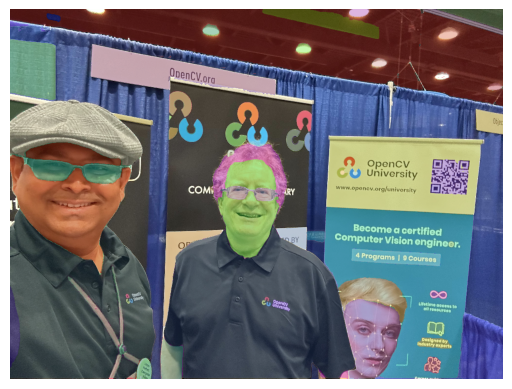

In [ ]:
plt.imshow(image)
show_anns(masks_1)
plt.axis("off")
plt.show()

Nearly everything in the image has been segmented. We can also change the default configuration of the `SamAutomaticMaskGenerator` class to generate masks more in tune with what we want.

Most of the parameters are self-explanatory, but in case you need more details, you can check the <a href="https://github.com/facebookresearch/segment-anything/blob/6fdee8f2727f4506cfbbe553e23b895e27956588/segment_anything/automatic_mask_generator.py#L59C9-L59C9" target="_blank">class documentation.</a>

In [ ]:
mask_generator_2 = SAM2AutomaticMaskGenerator.from_pretrained(
    model_id="facebook/sam2.1-hiera-large",
    points_per_side=48,
    pred_iou_thresh=0.90,
    stability_score_thresh=0.95,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=50,  # Requires opencv to run post-processing
)

In [ ]:
masks_2 = mask_generator_2.generate(image)

print("Number of masks:", len(masks_2))

Number of masks: 53


Let's plot both masks side-by-side to see the difference in the number of segmented regions.  

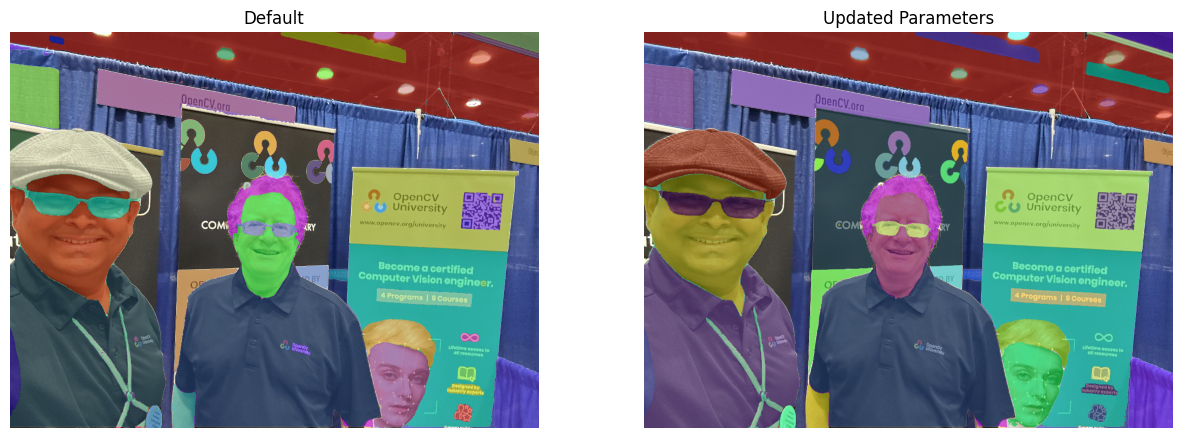

In [ ]:
plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1)
plt.imshow(image)
show_anns(masks_1, mask_strength=0.6)
plt.axis("off")
plt.title("Default")

plt.subplot(1, 2, 2)
plt.imshow(image)
show_anns(masks_2, mask_strength=0.6)
plt.axis("off")
plt.title("Updated Parameters")

plt.show()

**Note:** `SAM2` doesn't return the class of each masks. The colors in the above image are randomly generated and may not match one-to-one.

## 3 With Bounding Box as Prompts

<img src="https://www.dropbox.com/scl/fi/kxt9f05kyb9wfj3vjvdrm/promptable-sam2.png?rlkey=idgx7qn5te69cyr2dblat97n0&st=u2rfcfk1&dl=1">


In this section, we'll learn how to draw **bounding boxes** around *regions of interest* (ROI) images and use them as a **prompt** for SAM2 to generate masks.

There are other ways to prompt, such as providing an (x, y) point coordinate or drawing a mask over a region.

For a demonstration that runs well within the jupyter notebook, we will manually draw bounding boxes on an image using the `jupyter_bbox_widget` widget. You can also draw and import the bounding box information of an image using some external tool.

Before we begin, we are defining two helper functions:
    
1. `load_image(...)`: Load, resize and return the image and its file extension.

2. `encode_image(...)`: This function converts the image to bytes and encodes it via base64 encoding. The widget tool can also load an image using a filepath. But since we will be manipulating/resizing the image, we must pass the image byte information to the widget.

In [ ]:
def load_image(file_path, resize_to=None):
    image = cv2.imread(file_path, cv2.IMREAD_COLOR)[:, :, ::-1]

    if resize_to:
        image = resizeWithAspectRatio(image, resize_to=resize_to)
    ext = os.path.splitext(file_path)[-1]
    return image, ext


def encode_image(file_path, resize_to=None):
    image, ext  = load_image(file_path, resize_to=resize_to)
    image_bytes = cv2.imencode(ext, image[:, :, ::-1])[1]
    encoded     = str(base64.b64encode(image_bytes), "utf-8")
    return f"data:image/{ext};base64," + encoded

On Colab you need to execute the following cell to use the widget.

In [ ]:
ON_COLAB = True

if ON_COLAB:
    from google.colab import output
    output.enable_custom_widget_manager()

Load widget with class (optional) information and image. Draw bounding boxes over sections that you want to segment.

In [ ]:
widget = BBoxWidget(classes=["person", "board"])

widget.image = encode_image(file_path=DEMO_IMAGE_PATH, resize_to=1024)

widget

BBoxWidget(classes=['person', 'board'], colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564…

Once you done drawing the boxes, click on submit. You can access the bounding box information by:

```python
>>> widget.bboxes
[{'x': 0, 'y': 180, 'width': 303, 'height': 587, 'label': 'person'},
 {'x': 309, 'y': 276, 'width': 408, 'height': 489, 'label': 'person'},
 {'x': 652, 'y': 260, 'width': 334, 'height': 506, 'label': 'board'}]
```

In [ ]:
# widget.bboxes

In interest of time, we already have the annotation information for the image that we will use.

In [ ]:
bboxes = widget.bboxes = [
    {"x": 0,   "y": 180, "width": 303, "height": 587, "label": "person"},
    {"x": 309, "y": 276, "width": 408, "height": 489, "label": "person"},
    {"x": 652, "y": 260, "width": 334, "height": 506, "label": "board"},
]

We can see the bounding box information is a list of dictionaries. Each dictionary contains the following info:

1. Starting `x` position of the box.
2. Starting `y` position of the box.
3. Box `width`
4. Box `height`
5. Box `label`

---

However, SAM requires bounding box information in the format `(x1, y1, x2, y2)`. These are the top-left corner and bottom-right coordinates of the box.

In [ ]:
box_annotations = np.array(
    [
        [box["x"], box["y"], box["x"] + box["width"], box["y"] + box["height"]]
        for box in widget.bboxes
    ]
)

box_annotations

array([[  0, 180, 303, 767],
       [309, 276, 717, 765],
       [652, 260, 986, 766]])

* SAM2 only needs to process the input image once, and then we can prompt the image multiple times with different prompt types.

* The image processing step takes the longest time while generating masks via different prompts is close to real-time.

* To process images once and pass prompts to SAM, we need to use the `SamPredictor` class <a href="" target="_blank">[Class Documentation]</a>

In [ ]:
# Initialize SAM Predictor class
mask_predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2.1-hiera-large")

# Process image once.
with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    mask_predictor.set_image(load_image(file_path=DEMO_IMAGE_PATH, resize_to=1024)[0])

<img src="https://www.dropbox.com/scl/fi/mi9uxxovvqf10qdnib0ju/sam2-mask-decoder.png?rlkey=3gmw0nymp76wvmnqwjqfphzp8&st=khnd8otc&dl=1" width="80%">

* Another caveat is that `SamPredictor` class takes only one information prompt at a time. It can process only one bounding box or point or mask at a time. We need to loop over the all bounding boxes to generate masks for each of them.

* SAM returns outputs from all three heads When using the `multimask_output` boolean flag. We then have to select the mask that has the highest IoU score.

In [ ]:
pred_masks = []

with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    for box in box_annotations:
        masks, scores, logits = mask_predictor.predict(box=box, multimask_output=True)
        index = np.argmax(scores)
        pred_masks.append(masks[index])

Three binary masks for three  bounding box passed.

In [ ]:
pred_masks = np.array(pred_masks)
pred_masks.shape

(3, 768, 1024)

(-0.5, 1023.5, 767.5, -0.5)

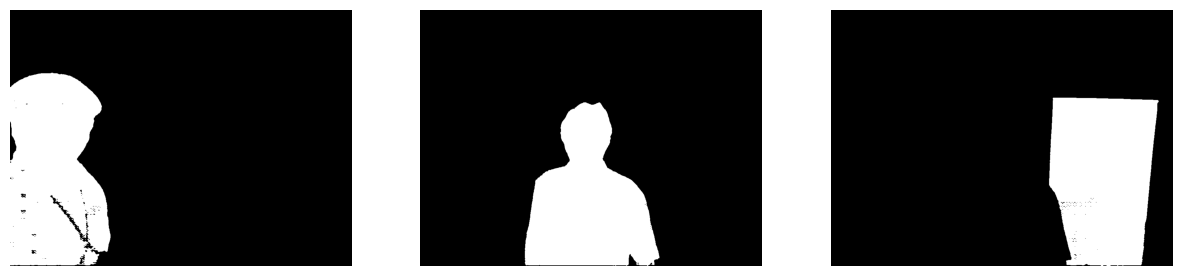

In [ ]:
plt.figure(figsize=(15, 10))
plt.subplot(1, 3, 1)
plt.imshow(pred_masks[0], cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(pred_masks[1], cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_masks[2], cmap="gray")
plt.axis("off")

**Exercise**

You can also use the `BBoxWidget` to put random points on the image. For that you simply need to click on the image. An "x" shaped point should be visible. Then using the `.bboxes` attribute you can get the "point" location. It's width and height should be `0`. You can pass (x, y) coordinate tot `SamPredictor` class to generate masks as well.

## 4 Generate Semantic Segmentation Dataset Using SAM2

In the previous section, we saw how we can prompt SAM to automatically generate masks. We'll take it a step further and simulate a practical scenario.

**Generating a segmentation dataset from scratch takes a lot of time and effort because we need to take extreme care in labeling each pixel by drawing a polygon or a mask around the object.**

To speed up this process, we can use SAM to generate segmentation masks from each bounding box prompt for all images of our dataset and export the entire dataset in Pascal VOC Segmentation format. In a practical scenario, one would use image annotation tools such as CVAT, labelme, or Roboflow to annotate the images. Preferably, image annotation tools allow the loading of external models to assist in the annotation process.

<img src="https://opencv.org/wp-content/uploads/2023/06/c2_m4_SAM_Semantic_mask_generation_example.jpg">


In this section, we'll do the following:

1. Perform bounding box annotations of our small dataset. This is similar to loading images of any annotation tool and annotating them with bounding boxes.

2. Run SAM2 and some post-processing code automatically generate a semantic segmentation mask for the image.


The masks generated by SAM may not be perfect every time, and it's up to the user to either use the generated masks as they are or fix them by using the annotation tool.


### 4.1 Helper Functions

First and foremost, we'll define some helper functions.

* `get_bboxes_xyxy(...)` & `segment(...)` function contains the code we used in the previous section. One is used to get bounding box information, and the other is used for generating masks using SAM.

* `num_to_rgb(...)` function converts the grayscale mask of (H, W) dimension into an RGB image. The input array pixel values denote the id of the class it belongs to.

* `draw_bbox(...)` is a visualization utility function to draw a bounding box on an image.

In [ ]:
def get_bboxes_xyxy(bounding_box_annotations):
    boxes = np.array(
        [
            [box["x"], box["y"], box["x"] + box["width"], box["y"] + box["height"]]
            for box in bounding_box_annotations
        ]
    )

    classes = np.array([box["label"] for box in bounding_box_annotations])
    return boxes, classes


# Function to convert a single channel mask representation to an RGB mask.
def num_to_rgb(num_arr, color_map):
    single_layer = np.squeeze(num_arr)
    output = np.zeros(num_arr.shape[:2] + (3,), dtype=np.int32)

    for k in color_map.keys():
        output[single_layer == k] = color_map[k]
    return output


def segment(sam_predictor, image, boxes):
    sam_predictor.set_image(image)

    results = []

    for box in boxes:
        masks, scores, logits = sam_predictor.predict(box=box, multimask_output=True)
        masks = masks.astype(bool)
        index = np.argmax(scores)
        results.append(masks[index])
    return np.array(results)


def draw_bbox(image, boxes, class_names, colors, thickness=2):
    overlay = image.copy()

    font_size = 0.25 + 0.07 * min(overlay.shape[:2]) / 100
    font_size = max(font_size, 0.5)
    font_size = min(font_size, 0.8)
    text_offset = 7
    font = cv2.FONT_HERSHEY_SIMPLEX

    for box, color, class_name in zip(boxes, colors, class_names):
        xmin = box[0]
        ymin = box[1]
        xmax = box[2]
        ymax = box[3]

        color = (int(color[0]), int(color[1]), int(color[2]))
        overlay = cv2.rectangle(overlay, (xmin, ymin), (xmax, ymax), color=color, thickness=thickness)

        display_text = f"{class_name}"
        (text_width, text_height), _ = cv2.getTextSize(display_text, font, font_size, 2)

        rect_final_loc = (xmin + text_width + text_offset, ymin - text_height - int(15 * font_size))
        cv2.rectangle(overlay,(xmin, ymin), rect_final_loc, color, thickness=-1)

        text_loc = (xmin + text_offset, ymin - int(10 * font_size))
        overlay = cv2.putText(overlay,display_text, text_loc, font, font_size, (255, 255, 255), 2, lineType=cv2.LINE_AA)

    return overlay

### 4.2 Annotate Images

Next, we are using the `BBoxWidget` to draw bounding box on some test images. We have pred-defined the classes we are going to annotate.

By executing the code cells below you'll be annotate all your images and annotation information will be saved within a `json` file. The code for annotation is taken from the <a href="https://github.com/gereleth/jupyter-bbox-widget/blob/main/examples/introduction.ipynb" target="_blank">official tutorial notebook</a> provided by the `jupyter_bbox_widget` library.  

We have also provided a pre-built `annotations.json` file that's already contains the bounding box information for each image.

In [ ]:
IMG_SIZE = 512

ROOT_IMG_DIR = r"images"
files = sorted(os.listdir(ROOT_IMG_DIR))

CLASSES = ["person", "plane", "car", "camera"]

# Use a pre-built annotations file.
annotations_path = "annotations.json"

# # Or create a new one.
# annotations_path = "annotations_new.json"

encode_image_p = partial(encode_image, resize_to=IMG_SIZE)

In [ ]:
annotations = {}

# A progress bar to show how far we got
w_progress = widgets.IntProgress(value=0, max=len(files), description="Progress")

# The bbox widget
w_bbox = BBoxWidget(image=encode_image_p(os.path.join(ROOT_IMG_DIR, files[0])), classes=CLASSES)

In [ ]:
# when Skip button is pressed we move on to the next file
@w_bbox.on_skip
def skip():
    w_progress.value += 1
    # open new image in the widget
    image_file = files[w_progress.value]
    w_bbox.image = encode_image_p(os.path.join(ROOT_IMG_DIR, image_file))
    # here we assign an empty list to bboxes but
    # we could also run a detection model on the file
    # and use its output for creating inital bboxes
    w_bbox.bboxes = []


# when Submit button is pressed we save current annotations
# and then move on to the next file
@w_bbox.on_submit
def submit():
    try:
        image_file = files[w_progress.value]
        # save annotations for current image
        annotations[image_file] = w_bbox.bboxes
        with open(annotations_path, "w") as f:
            json.dump(annotations, f, indent=4)

        # move on to the next file
        skip()

    except IndexError as e:
        print("Done")
        w_bbox.close_all()
        pass

In [ ]:
# Combine widgets into a container
w_container = widgets.VBox([w_progress, w_bbox])

# # Uncomment the next line to annotate images.
# w_container

### 4.3 Initialize Required Variable For Dataset Preparation

**Get all available classes**

In [ ]:
with open(annotations_path, 'r') as f:
    annotation_data = json.load(f)

annotation_data["image_1.jpg"]

[{'x': 308, 'y': 62, 'width': 39, 'height': 31, 'label': 'plane'},
 {'x': 314, 'y': 137, 'width': 39, 'height': 33, 'label': 'plane'},
 {'x': 171, 'y': 66, 'width': 40, 'height': 31, 'label': 'plane'}]

In [ ]:
CLASSES = deepcopy(w_bbox.classes)

In [ ]:
CLASSES.insert(0, "background")
CLASSES = tuple(CLASSES)
CLASSES

('background', 'person', 'plane', 'car', 'camera')

**Generate mask colors for all class.**

In [ ]:
R = np.array(np.arange(0, 256, 32))
G = np.roll(R, 2)
B = np.roll(R, 4)

COLOR_IDS = np.array(np.meshgrid(R, G, B)).T.reshape(-1, 3)

number_of_rows = COLOR_IDS.shape[0]
random_indices = np.random.choice(number_of_rows, size=len(CLASSES), replace=False)

COLORS = COLOR_IDS[random_indices]

**Generate dictionary mappings**

1. class name to class id: `cls2id`

2. class id  to class name: `id2cls`

3. class_id to RGB color: `id2color`

In [ ]:
id2cls = {cls_id: cls_name for cls_id, cls_name in enumerate(CLASSES)}
cls2id = {cls_name: cls_id for cls_id, cls_name in enumerate(CLASSES)}

id2color = {
    cls_id: tuple(COLORS[cls_id]) if cls_name != "background" else (0, 0, 0)
    for cls_id, cls_name in id2cls.items()
}

id2color, id2cls, cls2id

({0: (0, 0, 0),
  1: (160, 160, 96),
  2: (64, 224, 160),
  3: (0, 32, 32),
  4: (32, 160, 64)},
 {0: 'background', 1: 'person', 2: 'plane', 3: 'car', 4: 'camera'},
 {'background': 0, 'person': 1, 'plane': 2, 'car': 3, 'camera': 4})

### 4.4 Create Pascal VOC Semantic Segmentation Dataset

The *Pascal VOC Segmentation format* is as follows:

```html
VOC_Dataset
├── labelmap.txt # optional, required for non-VOC labels
├── ImageSets/
│   └── Segmentation/
│       └── default.txt # list of image names without extension
├── SegmentationClass/ # merged class masks
│   ├── image1.png
│   └── image2.png
└── SegmentationObject/ # merged instance masks
    ├── image1.png
    └── image2.png

```
---

```html
# labelmap.txt
# label : color (RGB) : 'body' parts : actions
background:0,128,0::
aeroplane:10,10,128::
bicycle:10,128,0::
bird:0,108,128::
boat:108,0,100::
bottle:18,0,8::
bus:12,28,0::
```

**Craete directory structure and required files as per the Pascal VOC format.**

In [ ]:
dataset_export_root = os.path.join(os.getcwd(), "dataset_voc")
images_folder       = os.path.join(dataset_export_root, "JPEGImages")
class_masks_loc     = os.path.join(dataset_export_root, "SegmentationClass")
imagesets_folder    = os.path.join(dataset_export_root, "ImageSets", "Segmentation")

# instance_loc        = os.path.join(dataset_export_root, "SegmentationObject")

label_map_file = os.path.join(dataset_export_root, "labelmap.txt")
imagesets_default_file = os.path.join(imagesets_folder, "default.txt")

os.makedirs(dataset_export_root, exist_ok=True)
os.makedirs(images_folder,       exist_ok=True)
os.makedirs(class_masks_loc,     exist_ok=True)
os.makedirs(imagesets_folder,    exist_ok=True)


# Creating "labelmap.txt" file # Contains class information.
with open(label_map_file, "w") as f:
    for cls_id, rgb in id2color.items():
        text = f"{id2cls[cls_id]}:{rgb[0]},{rgb[1]},{rgb[2]},::\n"
        f.write(text)

# Creating "defaults.txt" file. # Contains image names without extension.
with open(imagesets_default_file, "w") as f:
    for image_name in files:
        text = f"{os.path.splitext(image_name)[0]}\n"
        f.write(text)

In [ ]:
mask_predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2.1-hiera-large")

**Procedure:**

In the following code cell, we will bring everything together:

1. Iterate over each image in the dataset.
2. Get each image's bounding box and class information from the annotation file.
3. Generate a binary segmentation mask for each bounding box prompt.
4. Create a boolean `image_mask` array of shapes (H, W, #classes) to hold the binary mask of each class available in the annotations.
5. Iterate over the predicted masks and load them correctly inside the `image_mask` array.
6. Convert the 3d boolean mask array into a single channel grayscale using the argmax function. Each pixel value will be the class id of that pixel.
7. Convert the grayscale mask to an RGB mask.
8. Save the image & RGB mask.

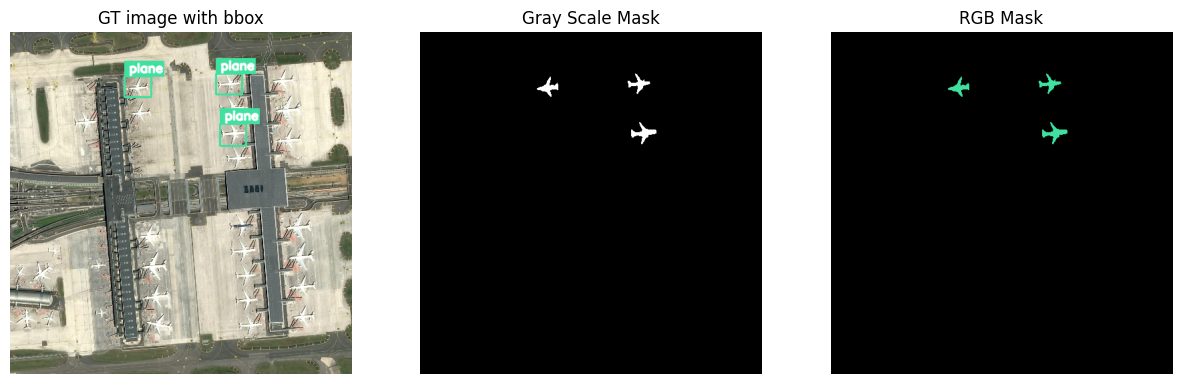

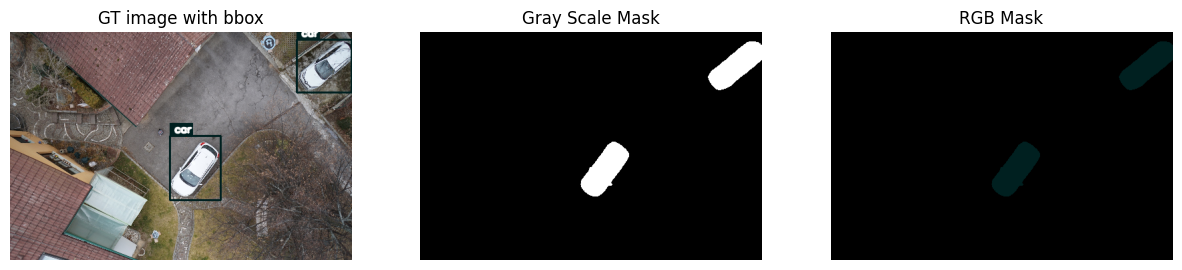

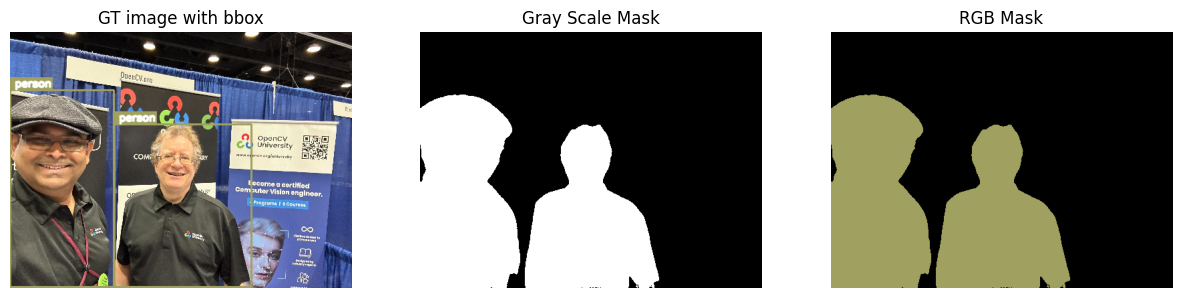

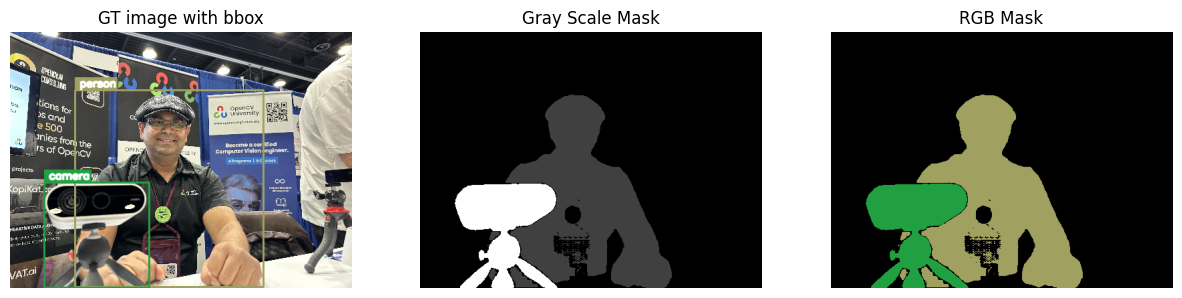

In [ ]:
with open(annotations_path, "r") as f:
    annotation_data = json.load(f)


for image_name in files:
    image_path = os.path.join(ROOT_IMG_DIR, image_name)
    image, ext = load_image(image_path, resize_to=IMG_SIZE)

    # Get bounding box (x1, y1, x2, y2) and class label for the current image.
    box_annotations, box_classes = get_bboxes_xyxy(annotation_data[image_name])

    # Generate Mask predictions.
    pred_masks = segment(sam_predictor=mask_predictor, image=image, boxes=box_annotations)

    # A 3d boolean matrix of size (img_H, img_W, #classes) to hold binary mask for each class.
    image_mask = np.zeros((*image.shape[:2], len(CLASSES))).astype(bool)

    # Loop over each predicted mask .
    for pred_msk, cls_name in zip(pred_masks, box_classes):
        # Get the class id
        cls_id = cls2id[cls_name]

        # Store
        image_mask[:, :, cls_id] += pred_msk

        # Fix --> pixel values > 1 occurs if there's an overlap between masks.
        image_mask[:, :, cls_id] = np.where(image_mask[:, :, cls_id], True, False)

    gray_mask = image_mask.argmax(axis=-1)

    # Convert the grayscale mask to RGB.
    rgb_mask = num_to_rgb(gray_mask, color_map=id2color)

    # Save Image & RGB mask.
    cv2.imwrite(os.path.join(images_folder, f"{image_name}.{ext}"), image[:, :, ::-1])
    cv2.imwrite(os.path.join(class_masks_loc, f"{image_name}.png"), rgb_mask[:, :, ::-1])


    plt.figure(figsize=(15, 12))

    plt.subplot(1, 3, 1)
    # Draw bounding box on image for visualization.
    box_colors = [id2color[cls2id[cls_name]] for cls_name in box_classes.tolist()]
    box_image = draw_bbox(image, box_annotations, box_classes, box_colors)
    plt.imshow(box_image)
    plt.title("GT image with bbox")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gray_mask, cmap="gray")
    plt.title("Gray Scale Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(rgb_mask)
    plt.title("RGB Mask")
    plt.axis("off")
    plt.show()
    plt.close()

## Conclusion

In this notebook, we showcased the powerful capabilities of the Segment Anything model from Meta for performing inference and generating segmentation masks for images. We presented a method to generate masks for the entire image or specific regions of interest by utilizing "bounding box prompts" with the model. Leveraging SAM's remarkable zero-shot generalization capability, we demonstrated its utility in automatically generating segmentation masks for various objects in images, enabling the creation of a segmentation dataset using solely bounding boxes. To ensure compatibility with popular annotation tools and facilitate further refinement, we saved the generated dataset in the widely used Pascal VOC format.